# Steam 리뷰 긍/부정 워드클라우드 파이프라인

**진행 순서**
1. **E**xtract - Transform - **L**oad (ETL)
2. 데이터 로그 (적재 결과 확인)
3. 데이터 전처리 (텍스트 클리닝, 토큰화, 불용어 제거)
4. 긍정/부정 워드클라우드 시각화

- 원본 데이터: `output.json`
- 저장소: SQLite `meccha.db`


## 0. 라이브러리 준비

In [1]:
# 필요한 라이브러리 설치 (최초 1회 실행)
# wordcloud가 없다면 아래 주석을 해제하고 실행하세요.
# !pip install wordcloud --quiet


In [2]:
import json
import re
import sqlite3
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', 100)

# 공통 설정값
JSON_PATH = "output.json"
DB_PATH = "meccha.db"
TABLE_NAME = "reviews"
KEEP_COLS = ["review_id", "sentiment", "review_text", "helpful_count"]


## 1. ETL

Extract / Transform / Load 각 단계를 함수로 정의합니다.


In [3]:
def extract(json_path: str) -> list:
    """Extract: JSON 원본 파일을 읽어 list[dict]로 반환"""
    with open(json_path, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
    print(f"[Extract] 원본 레코드 수: {len(raw_data)}")
    print(f"[Extract] 원본 컬럼(키) 목록: {list(raw_data[0].keys())}")
    return raw_data


In [4]:
def transform(raw_data: list, keep_cols: list) -> pd.DataFrame:
    """Transform: DataFrame으로 변환 후 필요한 컬럼만 선택"""
    df_raw = pd.DataFrame(raw_data)
    df = df_raw[keep_cols].copy()
    print(f"[Transform] 변환 후 shape: {df.shape}")
    return df


In [5]:
def load(df: pd.DataFrame, db_path: str, table_name: str) -> None:
    """Load: DataFrame을 SQLite DB에 저장"""
    conn = sqlite3.connect(db_path)
    try:
        df.to_sql(table_name, conn, if_exists="replace", index=False)
        conn.commit()
    finally:
        conn.close()
    print(f"[Load] '{db_path}' 에 '{table_name}' 테이블로 {len(df)}건 저장 완료")


In [6]:
def run_etl(json_path: str, db_path: str, table_name: str, keep_cols: list) -> pd.DataFrame:
    """ETL 전체 파이프라인 실행"""
    raw_data = extract(json_path)
    df = transform(raw_data, keep_cols)
    load(df, db_path, table_name)
    return df


df_etl = run_etl(JSON_PATH, DB_PATH, TABLE_NAME, KEEP_COLS)
df_etl.head()


[Extract] 원본 레코드 수: 2006
[Extract] 원본 컬럼(키) 목록: ['review_id', 'user_name', 'playtime_hours', 'sentiment', 'review_text', 'date_posted', 'helpful_count']
[Transform] 변환 후 shape: (2006, 4)
[Load] 'meccha.db' 에 'reviews' 테이블로 2006건 저장 완료


,review_id,sentiment,review_text,helpful_count
0,https://steamcommunity.com/profiles/76561198830268492/recommended/4704690/,Positive,This game is basically an art contest for the hider and an eye exam for the hunter.,2302
1,https://steamcommunity.com/id/cabalotpt/recommended/4704690/,Positive,1st - Congrats on having an original idea for a game. 2nd - I've been having a lot of fun with i...,3121
2,https://steamcommunity.com/profiles/76561198031356113/recommended/4704690/,Positive,People with art degrees finally have something to exel at. Great game.,794
3,https://steamcommunity.com/profiles/76561198811233852/recommended/4704690/,Positive,"What a fun game, devs have been relentless with the updates as well, have already improved so mu...",464
4,https://steamcommunity.com/id/jrxonfire/recommended/4704690/,Positive,Ultra fun. Couldn't ask more for this price. I'd pay even 10 EUR. Edit: I actually did pay 10 EU...,302


## 2. 데이터 로드

SQLite(`meccha.db`)에서 데이터를 다시 불러옵니다. 이후 단계는 JSON이 아니라 이 함수로 불러온 DataFrame을 사용합니다.


In [7]:
def load_data_from_db(db_path: str, table_name: str) -> pd.DataFrame:
    """DB 로드: SQLite에서 테이블 전체를 읽어 DataFrame으로 반환"""
    conn = sqlite3.connect(db_path)
    try:
        schema = pd.read_sql(f"PRAGMA table_info({table_name})", conn)
        sentiment_counts = pd.read_sql(
            f"SELECT sentiment, COUNT(*) AS cnt FROM {table_name} GROUP BY sentiment", conn
        )
        df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    finally:
        conn.close()

    print(f"[Data Load] '{table_name}' 테이블 로드 완료 - shape: {df.shape}")
    print("[Data Load] 테이블 스키마")
    display(schema)
    print("[Data Load] sentiment 분포")
    display(sentiment_counts)

    return df


df_db = load_data_from_db(DB_PATH, TABLE_NAME)
df_db.sample(5, random_state=42)


[Data Load] 'reviews' 테이블 로드 완료 - shape: (2006, 4)
[Data Load] 테이블 스키마


,cid,name,type,notnull,dflt_value,pk
0,0,review_id,TEXT,0,None,0
1,1,sentiment,TEXT,0,None,0
2,2,review_text,TEXT,0,None,0
3,3,helpful_count,INTEGER,0,None,0


[Data Load] sentiment 분포


,sentiment,cnt
0,Negative,349
1,Positive,1657


,review_id,sentiment,review_text,helpful_count
1805,https://steamcommunity.com/profiles/76561198431840581/recommended/4704690/,Positive,"honestly a super fun, goofy game to play with friends. It definitely still needs a few tweaks, t...",0
526,https://steamcommunity.com/id/7867885454564356s/recommended/4704690/,Positive,Easy value for your money. Tons of community maps for endless content. Have fun socializing and ...,0
393,https://steamcommunity.com/profiles/76561198221796960/recommended/4704690/,Positive,Got to fulfill my dreams of being horse testicles. 10/10,2
1401,https://steamcommunity.com/profiles/76561199387515027/recommended/4704690/,Negative,Cant even play the game at all. waste of $6,0
433,https://steamcommunity.com/id/MasterGir/recommended/4704690/,Positive,One of the most fun and replayable party games I've played in a long time.,0


## 3. 데이터 전처리

1. 결측/공백 리뷰 제거
2. 텍스트 정제 (소문자화, URL/특수문자/숫자 제거)
3. 토큰화 + 불용어(stopwords) 제거
4. 감성별 데이터 분리


In [8]:
# 불용어 목록 정의 (영어 리뷰 텍스트 기준)
STOPWORDS = set('''
a an the this that these those is are was were be been being
i you he she it we they me him her us them my your his its our their
and or but if then so because as until while of at by for with about
against between into through during before after above below to from
up down in out on off over under again further here there when where
why how all any both each few more most other some such no nor not
only own same than too very s t can will just don should now
have has had having do does did doing would could shall might must
game games play played playing get got one really much lot even also
still like just really actually thing things
'''.split())


In [9]:
def remove_missing_reviews(df: pd.DataFrame) -> pd.DataFrame:
    """결측치 및 빈 리뷰 제거"""
    df_clean = df.dropna(subset=["review_text", "sentiment"]).copy()
    df_clean["review_text"] = df_clean["review_text"].astype(str).str.strip()
    df_clean = df_clean[df_clean["review_text"] != ""]
    print(f"[전처리] 결측/빈 리뷰 제거: {len(df)}건 -> {len(df_clean)}건")
    return df_clean


def clean_text(text: str) -> str:
    """텍스트 정제: 소문자화, URL/특수문자/숫자 제거, 공백 정리"""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_and_remove_stopwords(text: str, stopwords: set = STOPWORDS) -> list:
    """토큰화 후 불용어 및 짧은 단어 제거"""
    tokens = text.split()
    return [t for t in tokens if t not in stopwords and len(t) > 2]


def split_by_sentiment(df: pd.DataFrame):
    """감성별로 DataFrame 분리"""
    df_positive = df[df["sentiment"].str.lower() == "positive"]
    df_negative = df[df["sentiment"].str.lower() == "negative"]
    print(f"[전처리] 긍정 리뷰: {len(df_positive)}건 / 부정 리뷰: {len(df_negative)}건")
    return df_positive, df_negative


def preprocess(df: pd.DataFrame):
    """전처리 파이프라인 전체 실행"""
    df_clean = remove_missing_reviews(df)
    df_clean["clean_text"] = df_clean["review_text"].apply(clean_text)
    df_clean["tokens"] = df_clean["clean_text"].apply(tokenize_and_remove_stopwords)
    df_positive, df_negative = split_by_sentiment(df_clean)
    return df_clean, df_positive, df_negative


df_clean, df_positive, df_negative = preprocess(df_db)
df_clean[["review_text", "clean_text", "tokens"]].head()


[전처리] 결측/빈 리뷰 제거: 2006건 -> 2003건
[전처리] 긍정 리뷰: 1654건 / 부정 리뷰: 349건


,review_text,clean_text,tokens
0,This game is basically an art contest for the hider and an eye exam for the hunter.,this game is basically an art contest for the hider and an eye exam for the hunter,"[basically, art, contest, hider, eye, exam, hunter]"
1,1st - Congrats on having an original idea for a game. 2nd - I've been having a lot of fun with i...,st congrats on having an original idea for a game nd i ve been having a lot of fun with it rd pl...,"[congrats, original, idea, fun, please, make, new, hud, menu, deserves, better, guys, better, sure]"
2,People with art degrees finally have something to exel at. Great game.,people with art degrees finally have something to exel at great game,"[people, art, degrees, finally, something, exel, great]"
3,"What a fun game, devs have been relentless with the updates as well, have already improved so mu...",what a fun game devs have been relentless with the updates as well have already improved so much...,"[what, fun, devs, relentless, updates, well, already, improved, isnt, worthy, price, range, atm,..."
4,Ultra fun. Couldn't ask more for this price. I'd pay even 10 EUR. Edit: I actually did pay 10 EU...,ultra fun couldn t ask more for this price i d pay even eur edit i actually did pay eur bought a...,"[ultra, fun, couldn, ask, price, pay, eur, edit, pay, eur, bought, copy, sis]"


## 4. 워드클라우드 시각화

긍정 리뷰와 부정 리뷰 각각에 대해 워드클라우드를 생성합니다.


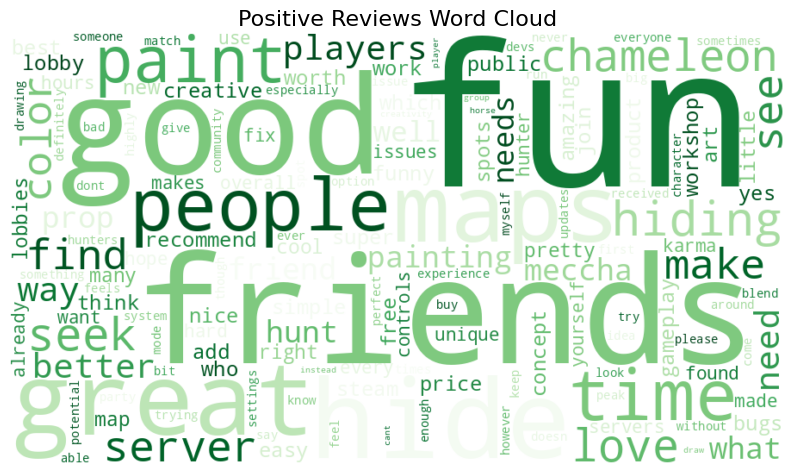

긍정 리뷰 상위 단어 TOP 10
  fun: 720
  friends: 362
  good: 305
  hide: 184
  great: 176
  maps: 155
  people: 150
  time: 143
  paint: 133
  hiding: 103


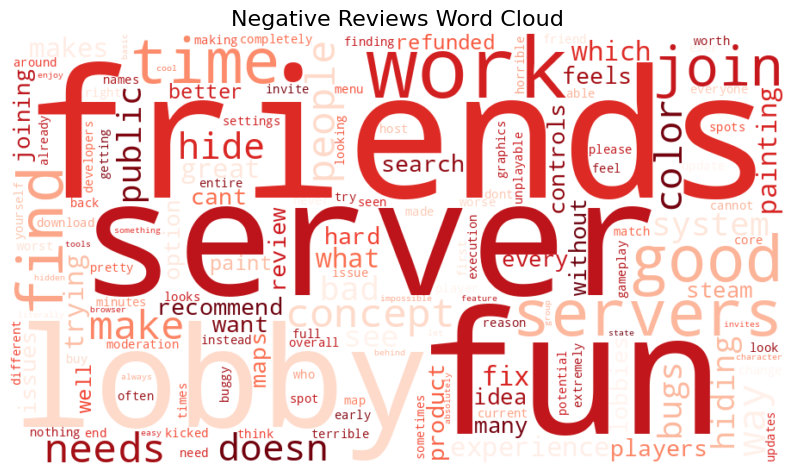

부정 리뷰 상위 단어 TOP 10
  friends: 122
  fun: 110
  server: 101
  lobby: 75
  work: 64
  servers: 60
  good: 58
  time: 57
  find: 56
  join: 51


In [10]:
def build_wordcloud(token_series: pd.Series, title: str, colormap: str) -> Counter:
    """토큰 리스트로부터 단어 빈도를 계산하고 워드클라우드를 그린 뒤 빈도(Counter)를 반환"""
    all_tokens = [tok for tokens in token_series for tok in tokens]
    freq = Counter(all_tokens)

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        colormap=colormap,
        max_words=150,
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

    return freq


def print_top_words(freq: Counter, label: str, top_n: int = 10) -> None:
    """상위 빈도 단어 출력"""
    print(f"{label} 상위 단어 TOP {top_n}")
    for word, cnt in freq.most_common(top_n):
        print(f"  {word}: {cnt}")


def generate_sentiment_wordclouds(df_positive: pd.DataFrame, df_negative: pd.DataFrame):
    """긍정/부정 워드클라우드를 한 번에 생성"""
    positive_freq = build_wordcloud(df_positive["tokens"], "Positive Reviews Word Cloud", colormap="Greens")
    print_top_words(positive_freq, "긍정 리뷰")

    negative_freq = build_wordcloud(df_negative["tokens"], "Negative Reviews Word Cloud", colormap="Reds")
    print_top_words(negative_freq, "부정 리뷰")

    return positive_freq, negative_freq


positive_freq, negative_freq = generate_sentiment_wordclouds(df_positive, df_negative)


## 요약

| 단계 | 함수 | 역할 |
|---|---|---|
| ETL | `extract`, `transform`, `load`, `run_etl` | JSON 추출 → 컬럼 정리 → SQLite 저장 |
| 데이터 로드 | `load_data_from_db` | `meccha.db`에서 데이터 재로드 + 스키마/분포 확인 |
| 전처리 | `remove_missing_reviews`, `clean_text`, `tokenize_and_remove_stopwords`, `split_by_sentiment`, `preprocess` | 정제 → 토큰화 → 불용어 제거 → 감성 분리 |
| 워드클라우드 | `build_wordcloud`, `print_top_words`, `generate_sentiment_wordclouds` | 긍정/부정 워드클라우드 시각화 |

각 단계가 함수화되어 있어 `run_etl(...)`, `load_data_from_db(...)`, `preprocess(...)`, `generate_sentiment_wordclouds(...)` 호출만으로 전체 파이프라인을 재실행할 수 있습니다.
